[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lifeng6666666/freeLearnLab/blob/main/reinforcement-learning/ch02_mdp_frozen_lake.ipynb)


In [ ]:
# Colab 环境准备：安装依赖并获取 viz_utils.py（本地 Jupyter 运行可跳过本格）
import os
if "google.colab" in str(get_ipython()):
    !pip install -q gymnasium
    if not os.path.exists('viz_utils.py'):
        !wget -q https://raw.githubusercontent.com/lifeng6666666/freeLearnLab/main/reinforcement-learning/viz_utils.py


# Ch02 - MDP 与 FrozenLake

理解马尔可夫决策过程五元组、贝尔曼方程，并在 FrozenLake 上做策略评估。

> 本 Notebook 配套《强化学习全面教程》PDF 使用。运行前请先执行 `pip install torch gymnasium numpy matplotlib tqdm`。

In [4]:
# 本单元导入本教程通用工具与第三方库
import numpy as np
import torch
import gymnasium as gym
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 中文字体配置（Linux 路径，macOS 用户请改用 Heiti SC 或 PingFang SC）
import os, platform
if platform.system() == 'Linux' and os.path.exists('/usr/share/fonts/truetype/chinese/NotoSansSC-Regular.ttf'):
    fm.fontManager.addfont('/usr/share/fonts/truetype/chinese/NotoSansSC-Regular.ttf')
plt.rcParams['font.sans-serif'] = ['Noto Sans SC', 'DejaVu Sans', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# PyTorch 设备选择
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch 版本: {torch.__version__}')
print(f'使用设备: {device}')
print(f'Gymnasium 版本: {gym.__version__}')


PyTorch 版本: 2.13.0+cpu
使用设备: cpu
Gymnasium 版本: 1.3.0


## 2.1 MDP 五元组

MDP = $(S, A, P, R, \gamma)$：
- $S$：状态空间
- $A$：动作空间
- $P(s'|s,a)$：状态转移函数
- $R(s,a)$：奖励函数
- $\gamma \in [0, 1)$：折扣因子

**马尔可夫性**：下一状态只依赖当前状态与动作，与历史无关。

$$P(s_{t+1} | s_0, a_0, \ldots, s_t, a_t) = P(s_{t+1} | s_t, a_t)$$

## 2.2 FrozenLake-v1：MDP 实例

4×4 网格世界，从起点 S 走到目标 G，避开冰洞 H。`is_slippery=True` 时，执行动作有 1/3 概率逆时针偏转 90°，1/3 概率顺时针偏转 90°，1/3 概率按原动作执行（模拟冰面湿滑）。

Gymnasium 提供 `env.unwrapped.P` 字段直接暴露 MDP，可用于动态规划求解。

In [5]:
env = gym.make('FrozenLake-v1', map_name='4x4', is_slippery=True)
print(f'状态数: {env.observation_space.n}')
print(f'动作数: {env.action_space.n}')
print('动作含义: 0=左 1=下 2=右 3=上')

# 查看状态 0 执行 '向右' (action=2) 的转移
print('\n状态0执行向右(action=2)的转移:')
for p, s_next, r, done in env.unwrapped.P[0][2]:
    print(f'  → 转{p:.2f} 到 状态{s_next}, r={r}, done={done}')

状态数: 16
动作数: 4
动作含义: 0=左 1=下 2=右 3=上

状态0执行向右(action=2)的转移:
  → 转0.33 到 状态4, r=0, done=False
  → 转0.33 到 状态1, r=0, done=False
  → 转0.33 到 状态0, r=0, done=False


## 2.3 价值函数与贝尔曼方程

**状态价值函数**：$V^\pi(s) = E_\pi[G_t | s_t = s]$

**动作价值函数**：$Q^\pi(s,a) = E_\pi[G_t | s_t = s, a_t = a]$

**贝尔曼期望方程**（迭代形式）：
$$V^\pi(s) = \sum_a \pi(a|s) \sum_{s'} P(s'|s,a) [R(s,a,s') + \gamma V^\pi(s')]$$

**贝尔曼最优方程**：
$$V^*(s) = \max_a \sum_{s'} P(s'|s,a) [R(s,a,s') + \gamma V^*(s')]$$

## 2.4 策略评估：迭代求解 V^π

对均匀随机策略 π 评估其价值函数。迭代直到 V 收敛（变化小于阈值 θ）。

In [6]:
def policy_eval(env, policy, gamma=0.99, theta=1e-8, max_iter=1000):
    """策略评估：迭代求解 V^π。"""
    nS = env.observation_space.n
    V = np.zeros(nS)
    for it in range(max_iter):
        delta = 0
        for s in range(nS):
            v = 0
            for a, pi_a in enumerate(policy[s]):
                for (p, s_next, r, done) in env.unwrapped.P[s][a]:
                    v += pi_a * p * (r + gamma * V[s_next] * (1 - done))
            delta = max(delta, abs(v - V[s]))
            V[s] = v
        if delta < theta:
            print(f'策略评估在第 {it+1} 步收敛')
            break
    return V

# 均匀随机策略
nS, nA = env.observation_space.n, env.action_space.n
uniform_policy = np.ones((nS, nA)) / nA
V = policy_eval(env, uniform_policy)
print('\n均匀随机策略下的状态价值 V^π:')
print(V.reshape(4, 4).round(3))

策略评估在第 54 步收敛

均匀随机策略下的状态价值 V^π:
[[0.012 0.01  0.019 0.009]
 [0.015 0.    0.039 0.   ]
 [0.033 0.084 0.138 0.   ]
 [0.    0.17  0.434 0.   ]]


## 2.5 可视化策略评估结果

将均匀随机策略下的状态价值 V^π 可视化在 FrozenLake 4×4 网格上。

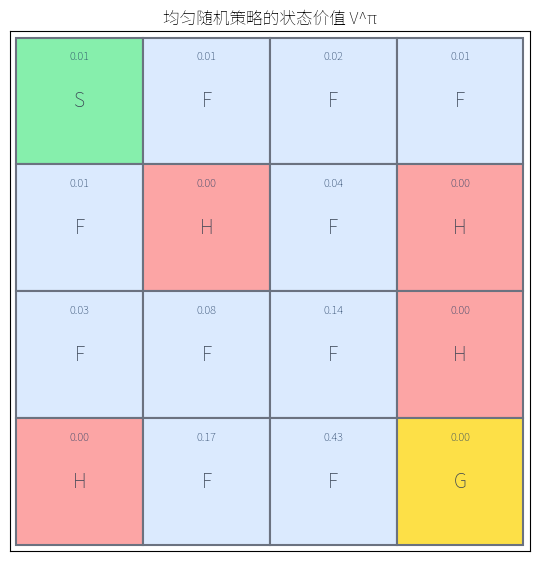

In [9]:
from viz_utils import visualize_frozen_lake
visualize_frozen_lake(V, title='均匀随机策略的状态价值 V^π')

## 2.6 小结

通过本章你应该掌握：
- MDP 五元组与马尔可夫性
- V 函数与 Q 函数的数学定义
- 贝尔曼方程的递推形式
- 如何用迭代策略评估求解 V^π

下一章将介绍 **策略迭代** 与 **值迭代**——已知 MDP 时求最优策略的两种方法。